In [1]:
import pandas as pd
import pandas as lag_plot
import matplotlib.pyplot as plt
import numpy as np
from statsmodels.tsa.arima.model import ARIMA
from sklearn.metrics import mean_squared_error
from pandas.plotting import lag_plot

df = pd.read_csv("Datasets/adc.txt")
df.head()

,Date,Open,High,Low,Close,Volume,OpenInt
0,2005-02-25,18.098,18.574,18.064,18.574,56882,0
1,2005-02-28,18.609,18.696,18.458,18.678,52472,0
2,2005-03-01,18.942,19.118,18.642,19.031,76573,0
3,2005-03-02,19.019,19.019,18.812,18.880,45705,0
4,2005-03-03,18.880,19.019,18.772,19.004,24394,0


In [2]:
print(df.head())
print(df.shape)
print(df.columns)

         Date    Open    High     Low   Close  Volume  OpenInt
0  2005-02-25  18.098  18.574  18.064  18.574   56882        0
1  2005-02-28  18.609  18.696  18.458  18.678   52472        0
2  2005-03-01  18.942  19.118  18.642  19.031   76573        0
3  2005-03-02  19.019  19.019  18.812  18.880   45705        0
4  2005-03-03  18.880  19.019  18.772  19.004   24394        0
(3201, 7)
Index(['Date', 'Open', 'High', 'Low', 'Close', 'Volume', 'OpenInt'], dtype='object')


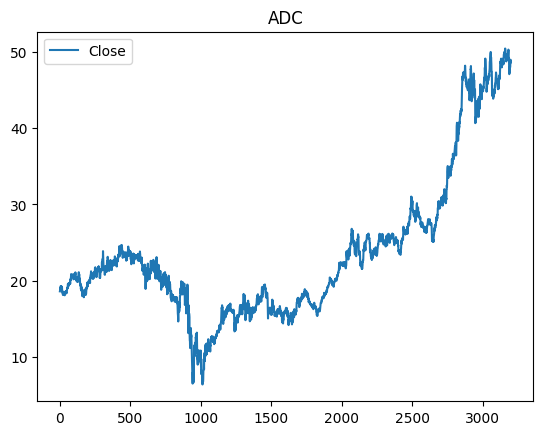

In [19]:
df[['Close']].plot()
plt.title("ADC")
plt.show()

Text(0.5, 1.0, 'ADC Cumulative Returns')

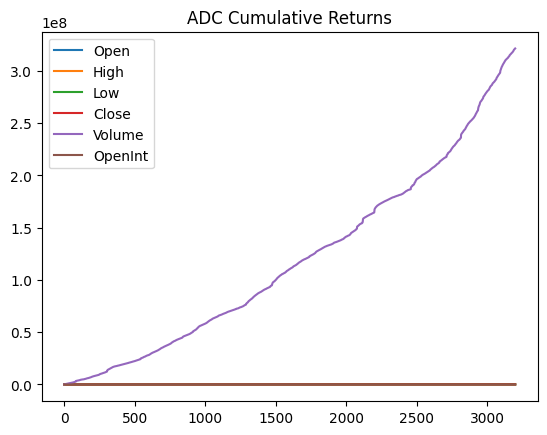

In [20]:
dr = df.cumsum()
dr.plot()
plt.title('ADC Cumulative Returns')

Text(0.5, 1.0, 'ADC Autocorrelation plot')

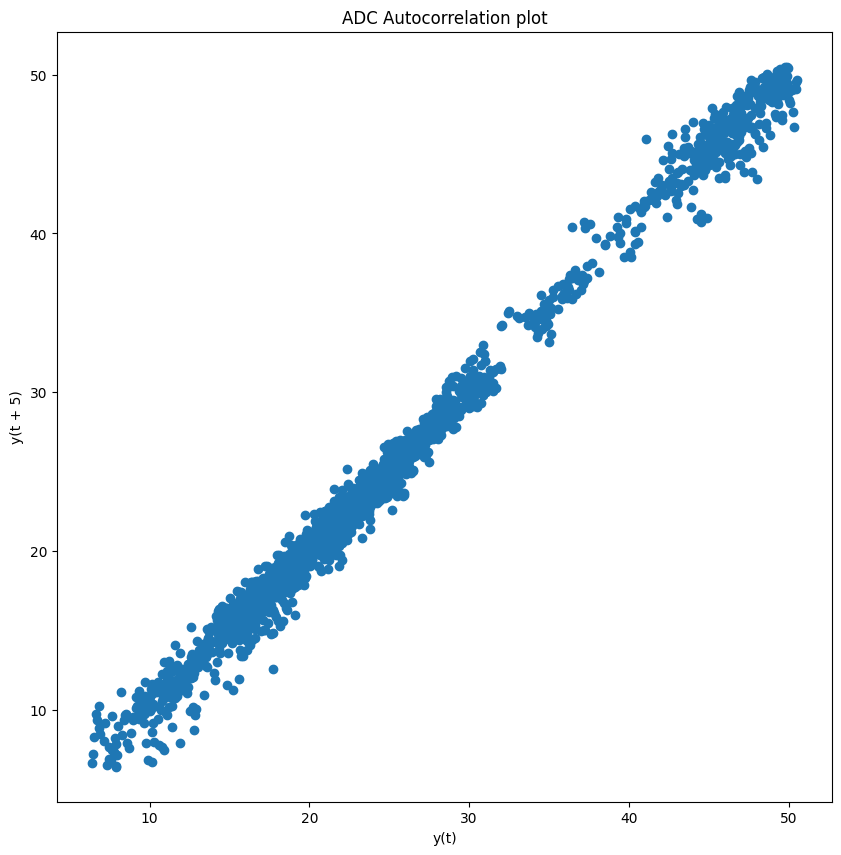

In [21]:
plt.figure(figsize=(10,10))
lag_plot(df['Open'], lag=5)
plt.title('ADC Autocorrelation plot')

ARIMA (AutoRegressive Integrated Moving Average) for Time Series Prediction

In [11]:
df['Date'][1857]

'2012-07-12'

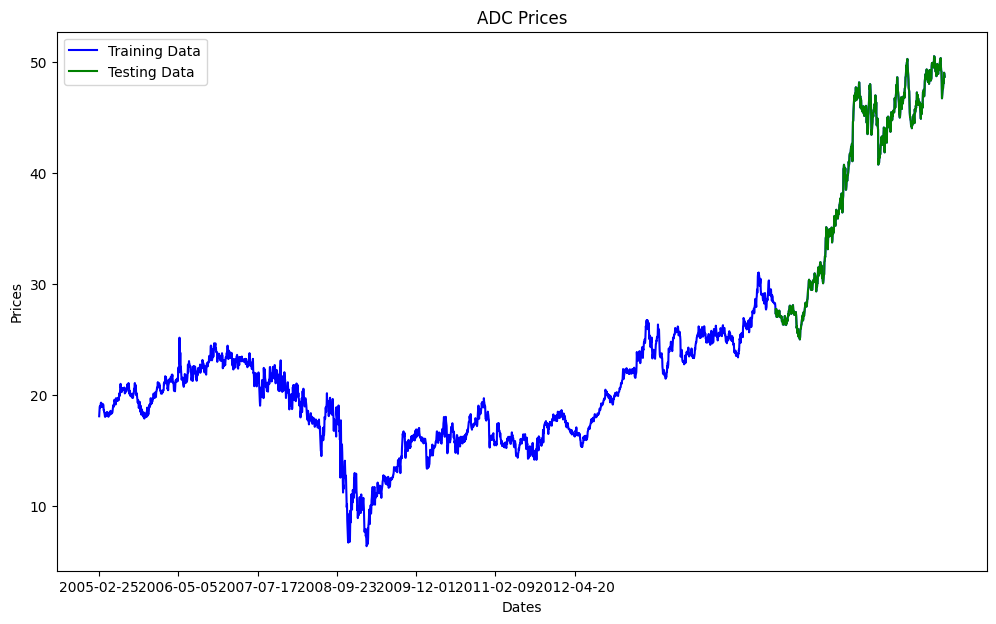

In [22]:
train_data, test_data = df[0:int(len(df)*0.8)], df[int(len(df)*0.8):]
plt.figure(figsize=(12,7))
plt.title('ADC Prices')
plt.xlabel('Dates')
plt.ylabel('Prices')
plt.plot(df['Open'], 'blue', label='Training Data')
plt.plot(test_data['Open'], 'green', label='Testing Data')
plt.xticks(np.arange(0,1857, 300), df['Date'][0:1857:300])
plt.legend()

In [13]:
def smape_kun(y_true, y_pred):
    return np.mean((np.abs(y_pred - y_true) * 200/ (np.abs(y_pred) + np.abs(y_true))))

In [15]:
train_ar = train_data['Open'].values
test_ar = test_data['Open'].values

history = [x for x in train_ar]
print(type(history))
predictions = list()
for t in range(len(test_ar)):
    model = ARIMA(history, order=(5,1,0))
    model_fit = model.fit()
    output = model_fit.forecast()
    yhat = output[0]
    predictions.append(yhat)
    obs = test_ar[t]
    history.append(obs)
    #print('predicted=%f, expected=%f' % (yhat, obs))
error = mean_squared_error(test_ar, predictions)
print('Testing Mean Squared Error: %.3f' % error)
error2 = smape_kun(test_ar, predictions)
print('Symmetric mean absolute percentage error: %.3f' % error2)

<class 'list'>
Testing Mean Squared Error: 0.249
Symmetric mean absolute percentage error: 0.930


In [1]:
plt.figure(figsize=(12,7))
plt.plot(df['Open'], 'green', color='blue', label='Training Data')
plt.plot(test_data.index, predictions, color='green', marker='o', linestyle='dashed',
         label='Predicted Price')
plt.plot(test_data.index, test_data['Open'], color='red', label='Actual Price')
plt.title('ADC Prices Prediction')
plt.xlabel('Dates')
plt.ylabel('Prices')
ticks = np.arange(0, len(df), int(len(df)/7))
plt.xticks(ticks, df['Date'].iloc[ticks])
plt.legend()

NameError: name 'plt' is not defined

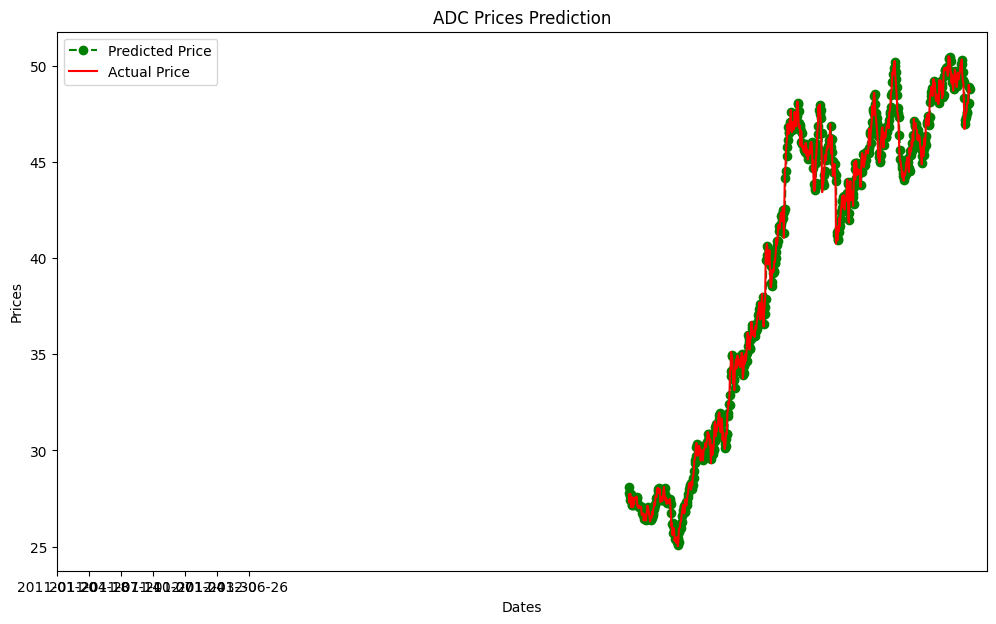

In [24]:
plt.figure(figsize=(12,7))
plt.plot(test_data.index, predictions, color='green', marker='o', linestyle='dashed',
         label='Predicted Price')
plt.plot(test_data.index, test_data['Open'], color='red', label='Actual Price')
plt.xticks(np.arange(1486,1856, 60), df['Date'][1486:1856:60])
plt.title('ADC Prices Prediction')
plt.xlabel('Dates')
plt.ylabel('Prices')
plt.legend()